In [5]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import cv2
import time
import pandas as pd
from scipy.ndimage import gaussian_filter, laplace, sobel

from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


I0000 00:00:1779826509.322489   36303 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779826509.322927   36303 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779826509.358926   36303 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779826510.284723   36303 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [6]:
# Single Neuron
model1 = Sequential()
model1.add(layers.Dense(units=1, input_shape=[3]))

model1.compile(optimizer='adam', loss='mae', metrics=['accuracy'])
model1.summary()

# Sequential NN
model2 = Sequential()
model2.add(Dense(units=4, input_shape=[3], activation="relu"))
model2.add(Dense(units=2, activation="relu"))
model2.add(Dense(units=1, activation="sigmoid"))
model2.compile(optimizer='adam', loss='mae', metrics=['accuracy'])
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

## Simple Sequential Model
Single Full Connected (Dense layer) -  flattened image array
![single dense layer](./public/dense_layer.jpg)

In [9]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0 # Normalize pixel values to be between 0.0 and 1.0

# model architecture
model = Sequential([
    layers.Flatten(input_shape=(28, 28)),    # Reshapes 2D images to 1D vectors
    layers.Dense(128, activation='relu'),    # Hidden layer with 128 neurons
    layers.Dropout(0.2),                     # Prevents overfitting by dropping 20% of units
    layers.Dense(10, activation='softmax')   # Output layer for 10 digit classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=32)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")
model.summary

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9148 - loss: 0.2936
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9572 - loss: 0.1431
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9661 - loss: 0.1087
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9719 - loss: 0.0889
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9759 - loss: 0.0754
313/313 - 1s - 3ms/step - accuracy: 0.9764 - loss: 0.0766

Test Accuracy: 0.9764


<bound method Model.summary of <Sequential name=sequential_9, built=True>>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ytest[0] :  7
ypred[0] :  7


<Axes: >

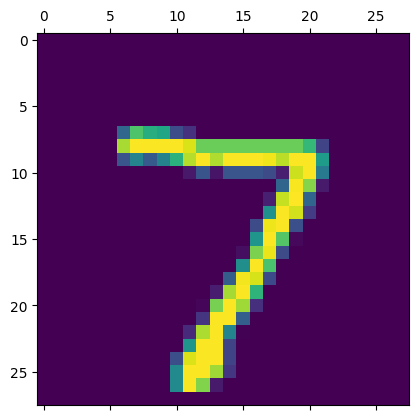

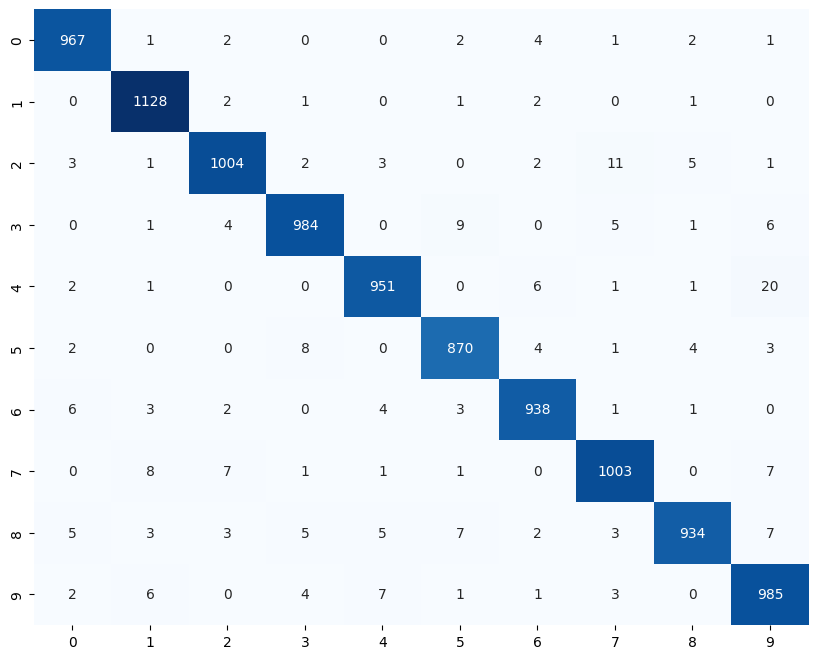

In [26]:
y_pred = model.predict(x_test) # probabilities
y_pred_labels = [np.argmax(i) for i in y_pred]
plt.matshow(x_test[0])
print("ytest[0] : ", y_test[0])
print("ypred[0] : ", y_pred_labels[0])

cm = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,      
    fmt="d",             # Format numbers as integers
    cmap="Blues",        
    cbar=False,          
    xticklabels=range(10), 
    yticklabels=range(10)
)

# Convolutional Neural Network
spatial feature extraction rather than a flattened array

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize the image data (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape the data to include a channel dimension (28, 28, 1) - Conv2D expects a 4D tensor
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels (0–9) since loss = categorical_crossentropy requires your labels to be explicit probability vectors. 
# If your target is the digit 7, it expects a 10-element array where index 7 is 1 and everything else is 0:

#sparse_categorical_crossentropy expects integer labels. If your target is the digit 7, it expects the label to simply be the integer 7. 
#Under the hood, TensorFlow automatically handles the math to map that single integer to your 10 output Softmax probabilities.

y_train = to_categorical(y_train, 10) 
y_test = to_categorical(y_test, 10)

In [29]:
# Sequential CNN model
model = Sequential()

# --- Layer 1: Convolutional Layer ---
# 32 filters, 3x3 kernel (filter), ReLU activation
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
# Output shape: (26, 26, 32), ie feature maps of 32 feature filters in the image (ie. 32 dimensions)

# --- Layer 2: Max Pooling Layer ---
# Reduces dimensionality using max in 2x2 shifting pools
model.add(MaxPooling2D(pool_size=(2, 2)))
# Output shape: (13, 13, 32)

# --- Layer 3: Flatten Layer ---
# Converts 2D feature maps to 1D vector
model.add(Flatten())
# Output shape: (13 * 13 * 32) = 5408

# --- Layer 4: Fully Connected (Dense) Layer ---
model.add(Dense(units=128, activation='relu'))

# --- Layer 5: Output Layer ---
# 10 neurons for 10 digit classes, softmax for probabilities
model.add(Dense(units=10, activation='softmax'))

# 6. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 7. Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

# 8. Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)


/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9500 - loss: 0.1715 - val_accuracy: 0.9789 - val_loss: 0.0623
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9831 - loss: 0.0554 - val_accuracy: 0.9810 - val_loss: 0.0539
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9883 - loss: 0.0375 - val_accuracy: 0.9860 - val_loss: 0.0414
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9919 - loss: 0.0266 - val_accuracy: 0.9861 - val_loss: 0.0435
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9851 - val_loss: 0.0475
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9851 - loss: 0.0475
Test accuracy: 0.9850999712944031


In [30]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081,888 (7.94 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,387,926 (5.29 MB)

In [6]:
# Function to build CNN model with variable filters

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


def create_cnn_model(num_filters):
    model = Sequential([
        Conv2D(filters=num_filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(units=128, activation='relu'),
        Dense(units=10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Test different filter sizes
filter_configs = [8, 16, 32, 64, 128]
results = []

for f in filter_configs:
    print(f"\n=== Training CNN with {f} filters ===")
    model = create_cnn_model(f)

    start_time = time.time()
    history = model.fit(x_train, y_train, epochs=3, batch_size=64, verbose=0, validation_data=(x_test, y_test))
    elapsed_time = time.time() - start_time

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "Filters": f,
        "Train Accuracy (last epoch)": history.history['accuracy'][-1],
        "Validation Accuracy (last epoch)": history.history['val_accuracy'][-1],
        "Test Accuracy": test_acc,
        "Training Time (s)": round(elapsed_time, 2)
    })

# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results)
print("\n=== Comparative Results Across Filter Configurations ===")
print(results_df.to_string(index=False))



=== Training CNN with 8 filters ===


/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779826524.229685   36303 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



=== Training CNN with 16 filters ===

=== Training CNN with 32 filters ===

=== Training CNN with 64 filters ===

=== Training CNN with 128 filters ===

=== Comparative Results Across Filter Configurations ===
 Filters  Train Accuracy (last epoch)  Validation Accuracy (last epoch)  Test Accuracy  Training Time (s)
       8                     0.981300                            0.9799         0.9799              25.24
      16                     0.986167                            0.9819         0.9819              33.87
      32                     0.988183                            0.9814         0.9814              51.67
      64                     0.989267                            0.9852         0.9852              76.81
     128                     0.990500                            0.9866         0.9866             112.94


In [7]:
# pre-processing input images for to be trained

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize (0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Define preprocessing filters
def apply_filter(data, filter_name):
    data_filtered = np.zeros_like(data)

    for i in range(data.shape[0]):
        img = data[i]
        if filter_name == "Original":
            data_filtered[i] = img
        elif filter_name == "Gaussian":
            data_filtered[i] = gaussian_filter(img, sigma=1)
        elif filter_name == "Sobel":
            sx = sobel(img, axis=0, mode='constant')
            sy = sobel(img, axis=1, mode='constant')
            data_filtered[i] = np.hypot(sx, sy)
        elif filter_name == "Laplacian":
            data_filtered[i] = laplace(img)
        elif filter_name == "Average":
            data_filtered[i] = cv2.blur(img, (3, 3))
        else:
            data_filtered[i] = img
    return data_filtered

# 4. One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 5. Function to create CNN
def create_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 6. Filter types to test
filter_types = ["Original", "Average", "Gaussian", "Sobel", "Laplacian"]

results = []

# 7. Train CNN on each filtered dataset
for ftype in filter_types:
    print(f"\n=== Training CNN with {ftype} filtered images ===")
    x_train_f = apply_filter(x_train, ftype)
    x_test_f = apply_filter(x_test, ftype)

    # Reshape for CNN
    x_train_f = x_train_f.reshape(-1, 28, 28, 1)
    x_test_f = x_test_f.reshape(-1, 28, 28, 1)

    # Create and train model
    model = create_cnn()
    start = time.time()
    history = model.fit(x_train_f, y_train, epochs=3, batch_size=64, verbose=0, validation_data=(x_test_f, y_test))
    duration = time.time() - start

    test_loss, test_acc = model.evaluate(x_test_f, y_test, verbose=0)

    results.append({
        "Filter Type": ftype,
        "Train Accuracy (last epoch)": round(history.history['accuracy'][-1], 4),
        "Validation Accuracy (last epoch)": round(history.history['val_accuracy'][-1], 4),
        "Test Accuracy": round(test_acc, 4),
        "Training Time (s)": round(duration, 2)
    })

# 8. Print comparison table
results_df = pd.DataFrame(results)
print("\n=== CNN Performance Comparison Across Filters ===")
print(results_df.to_string(index=False))



=== Training CNN with Original filtered images ===


/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== Training CNN with Average filtered images ===

=== Training CNN with Gaussian filtered images ===

=== Training CNN with Sobel filtered images ===

=== Training CNN with Laplacian filtered images ===

=== CNN Performance Comparison Across Filters ===
Filter Type  Train Accuracy (last epoch)  Validation Accuracy (last epoch)  Test Accuracy  Training Time (s)
   Original                       0.9880                            0.9835         0.9835              51.52
    Average                       0.9850                            0.9852         0.9852              52.35
   Gaussian                       0.9840                            0.9835         0.9835              48.50
      Sobel                       0.9892                            0.9867         0.9867              46.86
  Laplacian                       0.9859                            0.9800         0.9800              50.68
